# Stereo Visual Odometry — Final Clean Submission Notebook

This notebook is cleaned for the project submission requirements:

1. Load TUM VI datasets and official Kalibr calibration.
2. Run classical monocular VO baseline.
3. Run classical metric stereo VO using rectification, disparity/depth, 3D–2D PnP and RANSAC.
4. Evaluate according to the project protocol:
   - **Room2**: ATE/RPE with full ground truth.
   - **Corridor3 / Outdoors5**: start–end drift because ground truth is available only at the start/end.
5. Optionally run a **visual loop correction** only when explicitly enabled in the dataset config.
6. Save trajectory files in **TUM format**, summary CSVs, and plots.

Important project constraints respected here:
- No deep learning features or learned descriptors.
- Official calibration and official frame ranges are not modified.
- Monocular and stereo pipelines use the same codebase/modules.
- Stereo is evaluated with SE(3) / rigid alignment because it has metric scale.
- Monocular is evaluated with Sim(3) alignment because it is up-to-scale.


## 1. Setup, imports, and reproducibility


In [1]:
import sys
import os
import time
import json
import random
import platform
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
cv2.setRNGSeed(RANDOM_SEED)

ROOT_DIR = Path(r"C:\Users\User\Desktop\Stereo_vo")
PACKAGE_PARENT = ROOT_DIR / "stereo_vo1"

if str(PACKAGE_PARENT) not in sys.path:
    sys.path.insert(0, str(PACKAGE_PARENT))

print("Current notebook folder:", os.getcwd())
print("Root folder exists:", ROOT_DIR.exists())
print("Package parent exists:", PACKAGE_PARENT.exists())
print("stereo_vo folder exists:", (PACKAGE_PARENT / "stereo_vo").exists())
print("dataset.py exists:", (PACKAGE_PARENT / "stereo_vo" / "dataset.py").exists())

print("\n==============================")
print("REPRODUCIBILITY INFO")
print("==============================")
print("OS:", platform.platform())
print("Python:", sys.version.replace("\n", " "))
print("CPU count:", os.cpu_count())
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("Random seed:", RANDOM_SEED)

try:
    import scipy
    print("SciPy:", scipy.__version__)
except Exception as e:
    print("SciPy version unavailable:", e)

try:
    import psutil
    print("RAM total GB:", round(psutil.virtual_memory().total / (1024**3), 2))
except Exception:
    print("psutil not installed; RAM not printed.")

from stereo_vo.dataset import TumVIDataset
from stereo_vo.calibration import (
    load_kalibr_camchain,
    build_fisheye_rectifier,
    rectify_stereo_pair,
    load_camchain,
    get_camera_imu_transform,
)
from stereo_vo.monocular_vo import run_monocular_vo
from stereo_vo.evaluation import (
    load_gt_camera_poses,
    poses_to_xyz,
    sim3_align,
    rigid_align_3d,
    rpe_translation_rmse,
    poses_to_tum_array,
)

import importlib
import stereo_vo.features as features_module
import stereo_vo.stereo_vo as stereo_module

importlib.reload(features_module)
importlib.reload(stereo_module)

run_stereo_vo_rectified = stereo_module.run_stereo_vo_rectified
print("\nLoaded stereo module from:", stereo_module.__file__)


Current notebook folder: c:\Users\User\Downloads
Root folder exists: True
Package parent exists: True
stereo_vo folder exists: True
dataset.py exists: True

REPRODUCIBILITY INFO
OS: Windows-10-10.0.26200-SP0
Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
CPU count: 12
NumPy: 2.4.4
OpenCV: 4.10.0
Random seed: 42
SciPy: 1.17.0
RAM total GB: 15.73

Loaded stereo module from: C:\Users\User\Desktop\Stereo_vo\stereo_vo1\stereo_vo\stereo_vo.py


## 2. Dataset configuration


In [2]:
# ============================================================
# DATASET CONFIGURATION
# ============================================================
# Run this notebook once per dataset:
# ACTIVE_DATASET = "room2"
# ACTIVE_DATASET = "corridor3"
# ACTIVE_DATASET = "outdoors5"

ACTIVE_DATASET = "room2"      # required values: "room2", "corridor3", "outdoors5"

RUN_MONO = True
RUN_STEREO = True

# Optional correction. Keep False for pure baseline VO submission.
# If enabled, report it separately as "Stereo VO + visual loop correction", not raw stereo VO.
RUN_LOOP_CORRECTION = False

ROOM2_STEREO_PARAMS = dict(
    nfeatures=2200,
    ratio=0.75,
    top_k=200,

    min_disp=2.5,
    max_depth=4.0,
    min_depth=0.25,

    min_corr=40,
    min_inliers=35,

    t_norm_min=0.001,
    t_norm_max=0.15,
    rot_angle_max=20.0,

    use_hybrid=False,
    use_wls=False,
    max_reprojection_rmse=999.0,

    cross_check=False,
    use_fundamental=False,
)

CORRIDOR3_STEREO_PARAMS = {
    **ROOM2_STEREO_PARAMS,
    "nfeatures": 4000,
    "ratio": 0.75,
    "top_k": 500,
    "min_disp": 1.0,
    "max_depth": 8.0,
    "min_corr": 35,
    "min_inliers": 25,
    "t_norm_max": 0.30,
    "rot_angle_max": 30.0,
}

OUTDOORS5_STEREO_PARAMS = {
    **ROOM2_STEREO_PARAMS,
    "nfeatures": 5000,
    "ratio": 0.75,
    "top_k": 700,
    "min_disp": 1.0,
    "max_depth": 20.0,
    "min_corr": 35,
    "min_inliers": 25,
    "t_norm_max": 0.35,
    "rot_angle_max": 35.0,
}

DATASET_CONFIGS = {
    "room2": {
        "path": ROOT_DIR / "dataset-room2_512_16",
        "output_dir": ROOT_DIR / "outputs" / "room2_final_submission",
        "max_frames": None,
        "stereo_params": ROOM2_STEREO_PARAMS,
        "loop": {
            "enabled": False,
            "old_candidates": [650, 950, 1000],
            "new_candidates": [2100, 2150, 2300, 2450, 2600],
            "min_separation": 500,
            "min_loop_corr": 60,
            "min_loop_inliers": 50,
            "max_loop_rmse": 2.0,
            "loop_min_disp": 2.5,
            "loop_max_depth": 4.0,
        },
    },
    "corridor3": {
        "path": ROOT_DIR / "dataset-corridor3_512_16",
        "output_dir": ROOT_DIR / "outputs" / "corridor3_final_submission",
        "max_frames": None,
        "stereo_params": CORRIDOR3_STEREO_PARAMS,
        "loop": {
            "enabled": False,
            "old_candidates": list(range(800, 1201, 20)),
            "new_candidates": list(range(4300, 4701, 20)),
            "min_separation": 1000,
            "min_loop_corr": 30,
            "min_loop_inliers": 20,
            "max_loop_rmse": 2.0,
            "loop_min_disp": 1.0,
            "loop_max_depth": 8.0,
        },
    },
    "outdoors5": {
        "path": ROOT_DIR / "dataset-outdoors5_512_16",
        "output_dir": ROOT_DIR / "outputs" / "outdoors5_final_submission",
        "max_frames": None,
        "stereo_params": OUTDOORS5_STEREO_PARAMS,
        "loop": {"enabled": False},
    },
}

config = DATASET_CONFIGS[ACTIVE_DATASET]
OUTPUT_DIR = config["output_dir"]
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Active dataset:", ACTIVE_DATASET)
print("Dataset path:", config["path"])
print("Output dir:", OUTPUT_DIR)
print("Run mono:", RUN_MONO)
print("Run stereo:", RUN_STEREO)
print("Run optional loop correction:", RUN_LOOP_CORRECTION)


Active dataset: room2
Dataset path: C:\Users\User\Desktop\Stereo_vo\dataset-room2_512_16
Output dir: C:\Users\User\Desktop\Stereo_vo\outputs\room2_final_submission
Run mono: True
Run stereo: True
Run optional loop correction: False


## 3. Load dataset, official calibration, and rectifier


In [3]:
def load_dataset_context(name, config):
    dataset_dir = config["path"]
    dataset = TumVIDataset(dataset_dir)

    total_frames = len(dataset.left_images)
    if config.get("max_frames") is None:
        num_frames = total_frames
    else:
        num_frames = min(int(config["max_frames"]), total_frames)

    camchain_file = dataset_dir / "dso" / "camchain.yaml"
    st_calib = load_kalibr_camchain(camchain_file)

    imgL0 = cv2.imread(str(dataset.left_images[0]), cv2.IMREAD_GRAYSCALE)
    imgR0 = cv2.imread(str(dataset.right_images[0]), cv2.IMREAD_GRAYSCALE)

    if imgL0 is None or imgR0 is None:
        raise RuntimeError("Could not read first stereo pair. Check dataset paths.")

    h, w = imgL0.shape[:2]
    rectifier = build_fisheye_rectifier(st_calib, (w, h))

    return {
        "name": name,
        "dataset_dir": dataset_dir,
        "dataset": dataset,
        "num_frames": num_frames,
        "total_frames": total_frames,
        "camchain_file": camchain_file,
        "st_calib": st_calib,
        "rectifier": rectifier,
        "img_size": (w, h),
    }

ctx = load_dataset_context(ACTIVE_DATASET, config)

dataset = ctx["dataset"]
DATASET_DIR = ctx["dataset_dir"]
num_frames = ctx["num_frames"]
rectifier = ctx["rectifier"]
OUTPUT_DIR = config["output_dir"]

print("\n==============================")
print("Loaded dataset:", ACTIVE_DATASET)
print("==============================")
print("Total frames:", ctx["total_frames"])
print("Using frames:", num_frames)
print("Left images :", len(dataset.left_images))
print("Right images:", len(dataset.right_images))
print("GT file     :", dataset.gt_file)
print("Raw baseline [m]      :", ctx["st_calib"].baseline_raw)
print("Rectified baseline [m]:", rectifier.baseline)
print("Rectified fx          :", rectifier.fx)



Loaded dataset: room2
Total frames: 2882
Using frames: 2882
Left images : 2882
Right images: 2882
GT file     : C:\Users\User\Desktop\Stereo_vo\dataset-room2_512_16\mav0\mocap0\data.csv
Raw baseline [m]      : 0.10108726432764312
Rectified baseline [m]: 0.10108726432764312
Rectified fx          : 61.7543399205591


## 4. Rectification visual check


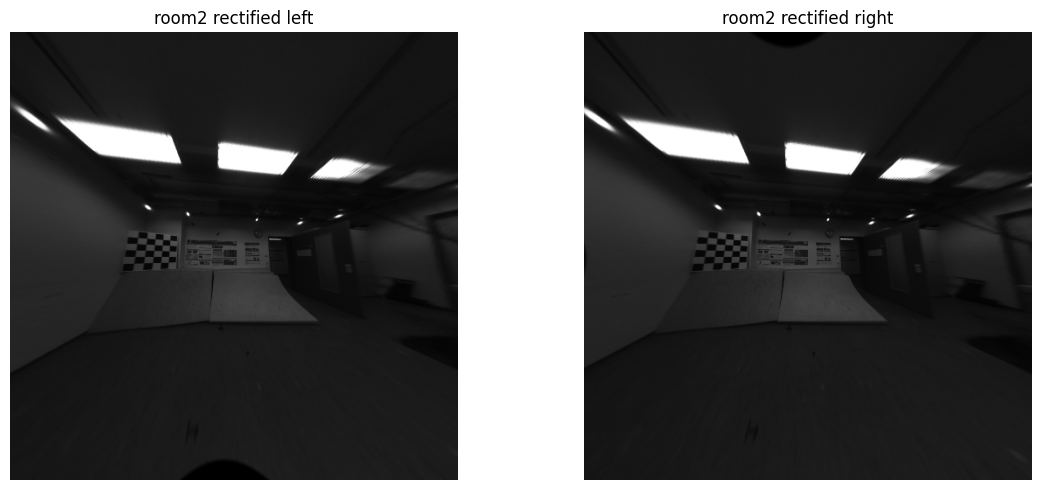

In [4]:
imgL0 = cv2.imread(str(dataset.left_images[0]), cv2.IMREAD_GRAYSCALE)
imgR0 = cv2.imread(str(dataset.right_images[0]), cv2.IMREAD_GRAYSCALE)
imgL_rect, imgR_rect = rectify_stereo_pair(imgL0, imgR0, rectifier)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(imgL_rect, cmap="gray")
ax[0].set_title(f"{ACTIVE_DATASET} rectified left")
ax[0].axis("off")
ax[1].imshow(imgR_rect, cmap="gray")
ax[1].set_title(f"{ACTIVE_DATASET} rectified right")
ax[1].axis("off")
plt.tight_layout()
plt.show()


## 5. Run monocular VO baseline


In [5]:
if RUN_MONO:
    print("\n==============================")
    print(f"Running Monocular VO baseline: {ACTIVE_DATASET}")
    print("==============================")

    start = time.time()

    poses_mono, traj_mono, stats_mono = run_monocular_vo(
        left_images=dataset.left_images,
        K=rectifier.K_rect,
        num_frames=num_frames,
        nfeatures=2000,
        ratio=0.75,
        top_k=200,
        ransac_threshold=1.0,
        min_inliers=30,
        rectifier=rectifier,
    )

    mono_runtime = time.time() - start
    mono_stats_df = pd.DataFrame(stats_mono)

    print("\nMONOCULAR VO DONE")
    print("Frames:", len(poses_mono))
    print("Runtime:", mono_runtime)
    print("Success rate:", 100.0 * mono_stats_df["success"].mean(), "%")
    display(mono_stats_df[["matches", "inliers"]].describe())
else:
    print("RUN_MONO=False, skipping monocular VO.")



Running Monocular VO baseline: room2

MONOCULAR VO DONE
Frames: 2882
Runtime: 74.65484356880188
Success rate: 97.6049982644915 %


,matches,inliers
count,2881.000000,2881.000000
mean,196.761888,131.701493
std,17.097805,41.459113
min,19.000000,1.000000
25%,200.000000,109.000000
50%,200.000000,141.000000
75%,200.000000,162.000000
max,200.000000,200.000000


## 6. Run stereo VO baseline


In [6]:
if RUN_STEREO:
    stereo_params = config["stereo_params"]

    print("\n==============================")
    print(f"Running Stereo VO baseline: {ACTIVE_DATASET}")
    print("==============================")
    print("Stereo params:")
    for k, v in stereo_params.items():
        print(f"  {k}: {v}")

    start = time.time()

    poses_stereo, traj_stereo, stats_stereo, tvec_norms = run_stereo_vo_rectified(
        dataset.left_images,
        dataset.right_images,
        rectifier,
        num_frames=num_frames,
        **stereo_params,
    )

    stereo_runtime = time.time() - start
    stereo_stats_df = pd.DataFrame(stats_stereo)

    print("\nSTEREO VO DONE")
    print("Frames:", len(poses_stereo))
    print("Runtime:", stereo_runtime)
    print("Success rate:", 100.0 * stereo_stats_df["success"].mean(), "%")
    display(stereo_stats_df[["matches", "corr_3d2d", "inliers", "t_norm", "rot_angle", "reproj_rmse"]].describe())
else:
    print("RUN_STEREO=False, skipping stereo VO.")



Running Stereo VO baseline: room2
Stereo params:
  nfeatures: 2200
  ratio: 0.75
  top_k: 200
  min_disp: 2.5
  max_depth: 4.0
  min_depth: 0.25
  min_corr: 40
  min_inliers: 35
  t_norm_min: 0.001
  t_norm_max: 0.15
  rot_angle_max: 20.0
  use_hybrid: False
  use_wls: False
  max_reprojection_rmse: 999.0
  cross_check: False
  use_fundamental: False

STEREO VO DONE
Frames: 2882
Runtime: 128.85544204711914
Success rate: 99.44463727872267 %


,matches,corr_3d2d,inliers,t_norm,rot_angle,reproj_rmse
count,2881.000000,2881.000000,2881.000000,2868.000000,2868.000000,2865.000000
mean,196.678237,148.952447,124.258244,0.049969,2.772339,0.857056
std,17.386065,36.281981,31.258998,0.014459,1.744732,0.109657
min,19.000000,19.000000,0.000000,0.000369,0.007855,0.150629
25%,200.000000,122.000000,103.000000,0.047502,1.665688,0.797719
50%,200.000000,157.000000,126.000000,0.053228,2.416182,0.865960
75%,200.000000,179.000000,147.000000,0.057301,3.356493,0.929633
max,200.000000,200.000000,198.000000,0.110262,11.868763,1.175623


## 7. Load ground truth and select the correct evaluation protocol


In [9]:
# ============================================================
# GROUND TRUTH LOADING + PROJECT EVALUATION PROTOCOL
# ============================================================
# IMPORTANT:
# - GT is used ONLY for evaluation.
# - GT is NOT used to correct, tune, filter, or modify VO.
# - GT is NOT clipped.
# - GT is NOT changed.
# - For Room2, evaluate only image timestamps that overlap GT range.
#   This is not deleting GT; it only avoids evaluating frames where GT does not exist.
# - For Corridor3 / Outdoors5, use first and last GT-covered segments for start-end drift.
# ============================================================

import numpy as np
from scipy.spatial.transform import Rotation as R, Slerp

# ------------------------------------------------------------
# Load official GT camera poses
# ------------------------------------------------------------
raw_calib = load_camchain(DATASET_DIR / "dso" / "camchain.yaml")
T_cam0_imu = get_camera_imu_transform(raw_calib, cam_key="cam0")

gt_ts, gt_cam_poses = load_gt_camera_poses(dataset.gt_file, T_cam0_imu)
image_ts = np.array(dataset.timestamps_ns[:num_frames], dtype=np.int64)

gt_ts = np.asarray(gt_ts, dtype=np.int64)
gt_cam_poses = list(gt_cam_poses)

# Sort GT and remove duplicate timestamps only
order = np.argsort(gt_ts)
gt_ts = gt_ts[order]
gt_cam_poses = [gt_cam_poses[i] for i in order]

unique_mask = np.ones(len(gt_ts), dtype=bool)
unique_mask[1:] = gt_ts[1:] != gt_ts[:-1]

gt_ts = gt_ts[unique_mask]
gt_cam_poses = [p for p, keep in zip(gt_cam_poses, unique_mask) if keep]

print("==============================")
print("GT LOADED FOR EVALUATION ONLY")
print("==============================")
print("Dataset:", ACTIVE_DATASET)
print("Image frames:", len(image_ts))
print("GT samples:", len(gt_ts))
print("Image first timestamp:", image_ts[0])
print("Image last timestamp :", image_ts[-1])
print("GT first timestamp   :", gt_ts[0])
print("GT last timestamp    :", gt_ts[-1])


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def split_contiguous_indices(indices):
    indices = np.asarray(indices, dtype=int)

    if len(indices) == 0:
        return []

    breaks = np.where(np.diff(indices) > 1)[0]

    segments = []
    start = 0

    for b in breaks:
        segments.append(indices[start:b + 1])
        start = b + 1

    segments.append(indices[start:])

    return segments


def split_gt_by_time_gaps(gt_ts, gap_threshold_sec=0.1):
    """
    Split GT into continuous timestamp segments.
    This does not delete GT. It only identifies gaps.
    """
    gt_ts = np.asarray(gt_ts, dtype=np.int64)

    if len(gt_ts) == 0:
        return []

    gaps_sec = np.diff(gt_ts) * 1e-9
    break_idx = np.where(gaps_sec > gap_threshold_sec)[0]

    segments = []
    start = 0

    for b in break_idx:
        end = b + 1
        segments.append((start, end))
        start = end

    segments.append((start, len(gt_ts)))

    return segments


def interpolate_gt_poses_inside_range(query_ts, gt_ts_local, gt_poses_local):
    """
    Interpolate GT only for query timestamps inside the given GT range.
    No clipping. No extrapolation.
    """
    query_ts = np.asarray(query_ts, dtype=np.int64)
    gt_ts_local = np.asarray(gt_ts_local, dtype=np.int64)

    if len(query_ts) == 0:
        return []

    if query_ts[0] < gt_ts_local[0] or query_ts[-1] > gt_ts_local[-1]:
        raise ValueError(
            "Query timestamps are outside GT range. "
            "This function does not clip or extrapolate GT."
        )

    gt_xyz = np.array([T[:3, 3] for T in gt_poses_local], dtype=np.float64)
    gt_rot = R.from_matrix(np.array([T[:3, :3] for T in gt_poses_local]))

    t0 = gt_ts_local[0]
    gt_t_sec = (gt_ts_local - t0) * 1e-9
    q_t_sec = (query_ts - t0) * 1e-9

    interp_xyz = np.column_stack([
        np.interp(q_t_sec, gt_t_sec, gt_xyz[:, 0]),
        np.interp(q_t_sec, gt_t_sec, gt_xyz[:, 1]),
        np.interp(q_t_sec, gt_t_sec, gt_xyz[:, 2]),
    ])

    slerp = Slerp(gt_t_sec, gt_rot)
    interp_rot = slerp(q_t_sec)

    out = []

    for p, rot in zip(interp_xyz, interp_rot):
        T = np.eye(4, dtype=np.float64)
        T[:3, :3] = rot.as_matrix()
        T[:3, 3] = p
        out.append(T)

    return out


def path_length_xyz(xyz):
    xyz = np.asarray(xyz, dtype=np.float64)

    if len(xyz) < 2:
        return 0.0

    return float(np.sum(np.linalg.norm(np.diff(xyz, axis=0), axis=1)))


def make_gt_arrays_for_image_frames(image_ts, eval_idx, gt_eval_poses):
    """
    Create GT arrays with the same length as image_ts.
    Frames without GT evaluation are NaN / None.
    This keeps indexing safe:
        gt_xyz_all[valid_idx]
    """
    gt_interp_all = [None] * len(image_ts)
    gt_xyz_all = np.full((len(image_ts), 3), np.nan, dtype=np.float64)

    gt_eval_xyz = poses_to_xyz(gt_eval_poses)

    for local_i, image_i in enumerate(eval_idx):
        gt_interp_all[int(image_i)] = gt_eval_poses[local_i]
        gt_xyz_all[int(image_i)] = gt_eval_xyz[local_i]

    return gt_interp_all, gt_xyz_all


# ------------------------------------------------------------
# Build evaluation variables
# ------------------------------------------------------------
ACTIVE_DATASET_LOWER = ACTIVE_DATASET.lower()
GT_GAP_THRESHOLD_SEC = 0.1

gt_segments = split_gt_by_time_gaps(
    gt_ts,
    gap_threshold_sec=GT_GAP_THRESHOLD_SEC
)

print("\nGT continuous segments:", gt_segments)

if ACTIVE_DATASET_LOWER == "room2":
    # --------------------------------------------------------
    # Room2: full GT evaluation
    # Do not remove GT.
    # Do not clip GT.
    # Only evaluate image frames inside GT timestamp range.
    # --------------------------------------------------------
    valid_idx = np.where(
        (image_ts >= gt_ts[0]) &
        (image_ts <= gt_ts[-1])
    )[0].astype(int)

    outside_count = len(image_ts) - len(valid_idx)

    if len(valid_idx) == 0:
        raise RuntimeError("No image timestamps overlap the Room2 GT timestamp range.")

    gt_eval_poses = interpolate_gt_poses_inside_range(
        image_ts[valid_idx],
        gt_ts,
        gt_cam_poses
    )

    gt_interp_all, gt_xyz_all = make_gt_arrays_for_image_frames(
        image_ts,
        valid_idx,
        gt_eval_poses
    )

    valid_segments = split_contiguous_indices(valid_idx)

    print("\n==============================")
    print("ROOM2 EVALUATION MODE")
    print("==============================")
    print("GT is not changed.")
    print("GT is not clipped.")
    print("VO trajectory is kept for all frames.")
    print("Evaluation uses image frames inside GT timestamp range only.")
    print("Total image frames:", len(image_ts))
    print("Evaluation frames:", len(valid_idx))
    print("Frames outside GT range, not evaluated:", outside_count)
    print("Evaluation frame range:", int(valid_idx[0]), "->", int(valid_idx[-1]))
    print("Valid eval segments:", [(int(s[0]), int(s[-1]), len(s)) for s in valid_segments])

    # Compatibility aliases for later evaluation cells
    full_eval_idx = valid_idx
    gt_eval_xyz = gt_xyz_all[valid_idx]
    gt_eval_poses_valid = [gt_interp_all[i] for i in valid_idx]

else:
    # --------------------------------------------------------
    # Corridor3 / Outdoors5: start-end drift only
    # Use first and last GT-covered segments.
    # Do not evaluate middle no-GT interval.
    # --------------------------------------------------------
    eval_segments = []

    for seg_id, (a, b) in enumerate(gt_segments):
        seg_gt_ts = gt_ts[a:b]
        seg_gt_poses = gt_cam_poses[a:b]

        img_idx = np.where(
            (image_ts >= seg_gt_ts[0]) &
            (image_ts <= seg_gt_ts[-1])
        )[0].astype(int)

        if len(img_idx) == 0:
            continue

        gt_interp_seg = interpolate_gt_poses_inside_range(
            image_ts[img_idx],
            seg_gt_ts,
            seg_gt_poses
        )

        gt_xyz_seg = poses_to_xyz(gt_interp_seg)

        eval_segments.append({
            "seg_id": seg_id,
            "gt_start": int(a),
            "gt_end": int(b - 1),
            "image_idx": img_idx,
            "image_start": int(img_idx[0]),
            "image_end": int(img_idx[-1]),
            "num_image_frames": int(len(img_idx)),
            "gt_poses_interp": gt_interp_seg,
            "gt_xyz_interp": gt_xyz_seg,
            "gt_path_length_m": path_length_xyz(gt_xyz_seg),
            "gt_start_end_m": float(np.linalg.norm(gt_xyz_seg[-1] - gt_xyz_seg[0])),
        })

    if len(eval_segments) < 2:
        raise RuntimeError(
            f"{ACTIVE_DATASET}: expected at least two GT-covered segments "
            "for start-end drift evaluation."
        )

    start_eval_segment = eval_segments[0]
    end_eval_segment = eval_segments[-1]

    start_idx = start_eval_segment["image_idx"]
    end_idx = end_eval_segment["image_idx"]

    gt_start_poses = start_eval_segment["gt_poses_interp"]
    gt_end_poses = end_eval_segment["gt_poses_interp"]

    gt_start_xyz = start_eval_segment["gt_xyz_interp"]
    gt_end_xyz = end_eval_segment["gt_xyz_interp"]

    valid_idx = np.concatenate([start_idx, end_idx]).astype(int)
    valid_segments = [start_idx, end_idx]

    gt_interp_all = [None] * len(image_ts)
    gt_xyz_all = np.full((len(image_ts), 3), np.nan, dtype=np.float64)

    for local_i, image_i in enumerate(start_idx):
        gt_interp_all[int(image_i)] = gt_start_poses[local_i]
        gt_xyz_all[int(image_i)] = gt_start_xyz[local_i]

    for local_i, image_i in enumerate(end_idx):
        gt_interp_all[int(image_i)] = gt_end_poses[local_i]
        gt_xyz_all[int(image_i)] = gt_end_xyz[local_i]

    print("\n==============================")
    print("START-END DRIFT EVALUATION MODE")
    print("==============================")
    print("Dataset:", ACTIVE_DATASET)
    print("GT is not changed.")
    print("VO trajectory is kept for all frames.")
    print("Middle image frames exist, but no GT evaluation is available there.")
    print("Start GT image frames:", int(start_idx[0]), "->", int(start_idx[-1]), "count:", len(start_idx))
    print("End GT image frames  :", int(end_idx[0]), "->", int(end_idx[-1]), "count:", len(end_idx))
    print("GT start segment path:", start_eval_segment["gt_path_length_m"])
    print("GT end segment path  :", end_eval_segment["gt_path_length_m"])
    print("GT start-end vector  :", gt_end_xyz[-1] - gt_start_xyz[0])
    print("GT start-end distance:", np.linalg.norm(gt_end_xyz[-1] - gt_start_xyz[0]))

GT LOADED FOR EVALUATION ONLY
Dataset: room2
Image frames: 2882
GT samples: 15477
Image first timestamp: 1520530731400018325
Image last timestamp : 1520530875454345641
GT first timestamp   : 1520530731382632018
GT last timestamp    : 1520530875449299018

GT continuous segments: [(0, np.int64(3100)), (np.int64(3100), np.int64(3852)), (np.int64(3852), np.int64(3855)), (np.int64(3855), np.int64(4653)), (np.int64(4653), np.int64(5475)), (np.int64(5475), np.int64(6272)), (np.int64(6272), np.int64(7112)), (np.int64(7112), np.int64(8049)), (np.int64(8049), np.int64(8882)), (np.int64(8882), np.int64(9783)), (np.int64(9783), np.int64(9785)), (np.int64(9785), np.int64(10562)), (np.int64(10562), np.int64(10563)), (np.int64(10563), np.int64(10568)), (np.int64(10568), np.int64(11365)), (np.int64(11365), np.int64(11380)), (np.int64(11380), 15477)]

ROOM2 EVALUATION MODE
GT is not changed.
GT is not clipped.
VO trajectory is kept for all frames.
Evaluation uses image frames inside GT timestamp range 

## 8. Evaluation functions


In [10]:
# ============================================================
# EVALUATION FUNCTIONS
# ============================================================

def path_length_xyz(xyz):
    xyz = np.asarray(xyz, dtype=np.float64)
    if len(xyz) < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(np.diff(xyz, axis=0), axis=1)))

def evaluate_full_gt(est_xyz_all, gt_xyz_all, eval_idx, mode="rigid", gap=20):
    """Room2 full-GT evaluation: ATE/RPE after alignment over all valid GT frames."""
    n = min(len(est_xyz_all), len(gt_xyz_all))
    idx = eval_idx[eval_idx < n]

    est_eval = est_xyz_all[idx]
    gt_eval = gt_xyz_all[idx]

    if mode == "sim3":
        aligned_eval, scale, R_align, t_align = sim3_align(est_eval, gt_eval)
    elif mode == "rigid":
        aligned_eval, R_align, t_align = rigid_align_3d(est_eval, gt_eval)
        scale = 1.0
    else:
        raise ValueError("mode must be 'sim3' or 'rigid'")

    errors = np.linalg.norm(aligned_eval - gt_eval, axis=1)

    return {
        "protocol": "full_gt_ate_rpe",
        "aligned_eval": aligned_eval,
        "gt_eval": gt_eval,
        "eval_idx": idx,
        "errors": errors,
        "ATE_RMSE_m": float(np.sqrt(np.mean(errors ** 2))),
        "RPE_RMSE_m": rpe_translation_rmse(aligned_eval, gt_eval, gap=gap),
        "start_end_drift_m": np.nan,
        "final_error_m": float(errors[-1]),
        "mean_error_m": float(errors.mean()),
        "median_error_m": float(np.median(errors)),
        "max_error_m": float(errors.max()),
        "scale": float(scale),
        "R_align": R_align,
        "t_align": t_align,
    }

def evaluate_start_end_drift(est_xyz_all, gt_xyz_all, valid_segments, mode="rigid"):
    """
    Corridor3/Outdoors5 evaluation:
    align on first GT-covered segment, then report end-segment/final drift.
    """
    if len(valid_segments) < 2:
        raise RuntimeError("Start-end drift requires at least two GT-covered segments.")

    start_idx = valid_segments[0]
    end_idx = valid_segments[-1]

    est_start = est_xyz_all[start_idx]
    gt_start = gt_xyz_all[start_idx]

    if mode == "sim3":
        aligned_start, scale, R_align, t_align = sim3_align(est_start, gt_start)
    elif mode == "rigid":
        aligned_start, R_align, t_align = rigid_align_3d(est_start, gt_start)
        scale = 1.0
    else:
        raise ValueError("mode must be 'sim3' or 'rigid'")

    aligned_all = (scale * (R_align @ est_xyz_all.T)).T + t_align

    start_errors = np.linalg.norm(aligned_all[start_idx] - gt_xyz_all[start_idx], axis=1)
    end_errors = np.linalg.norm(aligned_all[end_idx] - gt_xyz_all[end_idx], axis=1)

    vo_vec = aligned_all[end_idx[-1]] - aligned_all[start_idx[0]]
    gt_vec = gt_xyz_all[end_idx[-1]] - gt_xyz_all[start_idx[0]]
    drift_vec = vo_vec - gt_vec

    return {
        "protocol": "start_end_drift",
        "aligned_eval": aligned_all[np.r_[start_idx, end_idx]],
        "gt_eval": gt_xyz_all[np.r_[start_idx, end_idx]],
        "eval_idx": np.r_[start_idx, end_idx],
        "errors": np.r_[start_errors, end_errors],
        "ATE_RMSE_m": np.nan,
        "RPE_RMSE_m": np.nan,
        "start_alignment_RMSE_m": float(np.sqrt(np.mean(start_errors ** 2))),
        "end_RMSE_after_start_align_m": float(np.sqrt(np.mean(end_errors ** 2))),
        "start_end_drift_m": float(np.linalg.norm(drift_vec)),
        "drift_x_m": float(drift_vec[0]),
        "drift_y_m": float(drift_vec[1]),
        "drift_z_m": float(drift_vec[2]),
        "xy_drift_m": float(np.linalg.norm(drift_vec[:2])),
        "z_abs_drift_m": float(abs(drift_vec[2])),
        "final_error_m": float(end_errors[-1]),
        "mean_error_m": float(np.mean(end_errors)),
        "median_error_m": float(np.median(end_errors)),
        "max_error_m": float(np.max(end_errors)),
        "scale": float(scale),
        "R_align": R_align,
        "t_align": t_align,
        "start_eval_frames": int(len(start_idx)),
        "end_eval_frames": int(len(end_idx)),
    }

def evaluate_project(est_xyz_all, method_mode):
    """Dispatch evaluation according to dataset protocol."""
    if ACTIVE_DATASET == "room2":
        return evaluate_full_gt(est_xyz_all, gt_xyz_all, valid_idx, mode=method_mode, gap=20)
    return evaluate_start_end_drift(est_xyz_all, gt_xyz_all, valid_segments, mode=method_mode)

def apply_alignment_full(xyz_all, eval_result):
    return (eval_result["scale"] * (eval_result["R_align"] @ xyz_all.T)).T + eval_result["t_align"]

def success_stats(stats_df):
    if len(stats_df) == 0 or "success" not in stats_df.columns:
        return np.nan, np.nan
    success_rate = float(100.0 * stats_df["success"].mean())
    failure_count = int((~stats_df["success"].astype(bool)).sum())
    return success_rate, failure_count


## 9. Evaluate monocular and stereo baselines


In [11]:
# ============================================================
# EVALUATE MONOCULAR AND STEREO BASELINES
# ============================================================

summary_rows = []

if RUN_MONO:
    mono_xyz_all = poses_to_xyz(poses_mono)
    mono_eval = evaluate_project(mono_xyz_all, method_mode="sim3")
    mono_full_aligned = apply_alignment_full(mono_xyz_all, mono_eval)
    mono_success_rate, mono_failure_count = success_stats(mono_stats_df)

    summary_rows.append({
        "dataset": ACTIVE_DATASET,
        "method": "Monocular VO baseline",
        "protocol": mono_eval["protocol"],
        "alignment": "Sim(3)",
        "frames": len(poses_mono),
        "ATE_RMSE_m": mono_eval.get("ATE_RMSE_m", np.nan),
        "RPE_RMSE_m": mono_eval.get("RPE_RMSE_m", np.nan),
        "start_alignment_RMSE_m": mono_eval.get("start_alignment_RMSE_m", np.nan),
        "end_RMSE_after_start_align_m": mono_eval.get("end_RMSE_after_start_align_m", np.nan),
        "start_end_drift_m": mono_eval.get("start_end_drift_m", np.nan),
        "xy_drift_m": mono_eval.get("xy_drift_m", np.nan),
        "z_abs_drift_m": mono_eval.get("z_abs_drift_m", np.nan),
        "final_error_m": mono_eval["final_error_m"],
        "mean_error_m": mono_eval["mean_error_m"],
        "median_error_m": mono_eval["median_error_m"],
        "max_error_m": mono_eval["max_error_m"],
        "scale": mono_eval["scale"],
        "path_length_m": path_length_xyz(mono_xyz_all),
        "runtime_s": mono_runtime,
        "runtime_per_frame_s": mono_runtime / max(len(poses_mono), 1),
        "success_rate_percent": mono_success_rate,
        "failure_count": mono_failure_count,
    })

if RUN_STEREO:
    stereo_xyz_all = poses_to_xyz(poses_stereo)
    stereo_eval = evaluate_project(stereo_xyz_all, method_mode="rigid")
    stereo_full_aligned = apply_alignment_full(stereo_xyz_all, stereo_eval)
    stereo_success_rate, stereo_failure_count = success_stats(stereo_stats_df)

    summary_rows.append({
        "dataset": ACTIVE_DATASET,
        "method": "Stereo VO baseline",
        "protocol": stereo_eval["protocol"],
        "alignment": "Rigid SE(3)",
        "frames": len(poses_stereo),
        "ATE_RMSE_m": stereo_eval.get("ATE_RMSE_m", np.nan),
        "RPE_RMSE_m": stereo_eval.get("RPE_RMSE_m", np.nan),
        "start_alignment_RMSE_m": stereo_eval.get("start_alignment_RMSE_m", np.nan),
        "end_RMSE_after_start_align_m": stereo_eval.get("end_RMSE_after_start_align_m", np.nan),
        "start_end_drift_m": stereo_eval.get("start_end_drift_m", np.nan),
        "xy_drift_m": stereo_eval.get("xy_drift_m", np.nan),
        "z_abs_drift_m": stereo_eval.get("z_abs_drift_m", np.nan),
        "final_error_m": stereo_eval["final_error_m"],
        "mean_error_m": stereo_eval["mean_error_m"],
        "median_error_m": stereo_eval["median_error_m"],
        "max_error_m": stereo_eval["max_error_m"],
        "scale": stereo_eval["scale"],
        "path_length_m": path_length_xyz(stereo_xyz_all),
        "runtime_s": stereo_runtime,
        "runtime_per_frame_s": stereo_runtime / max(len(poses_stereo), 1),
        "success_rate_percent": stereo_success_rate,
        "failure_count": stereo_failure_count,
    })

baseline_summary = pd.DataFrame(summary_rows)
display(baseline_summary)


,dataset,method,protocol,alignment,frames,ATE_RMSE_m,RPE_RMSE_m,start_alignment_RMSE_m,end_RMSE_after_start_align_m,start_end_drift_m,...,final_error_m,mean_error_m,median_error_m,max_error_m,scale,path_length_m,runtime_s,runtime_per_frame_s,success_rate_percent,failure_count
0,room2,Monocular VO baseline,full_gt_ate_rpe,Sim(3),2882,1.217163,0.944623,NaN,NaN,NaN,...,0.276995,1.158651,1.255100,1.764299,0.00515,2812.000000,74.654844,0.025904,97.604998,69
1,room2,Stereo VO baseline,full_gt_ate_rpe,Rigid SE(3),2882,0.943861,0.338850,NaN,NaN,NaN,...,1.048050,0.836957,0.778668,2.127382,1.00000,143.309454,128.855442,0.044710,99.444637,16


## 10. Baseline trajectory plot


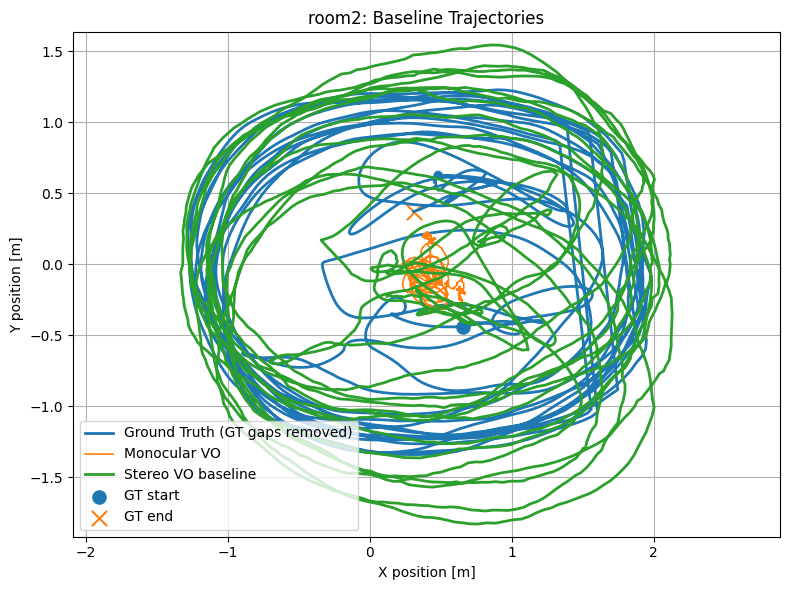

In [12]:
# ============================================================
# BASELINE TRAJECTORY PLOT
# ============================================================
# GT is broken at missing GT sections; VO estimates are continuous.

gt_plot = np.full_like(gt_xyz_all, np.nan)
gt_plot[valid_idx] = gt_xyz_all[valid_idx]

plt.figure(figsize=(8, 6))
plt.plot(gt_plot[:, 0], gt_plot[:, 1], label="Ground Truth (GT gaps removed)", linewidth=2)

if RUN_MONO:
    plt.plot(mono_full_aligned[:, 0], mono_full_aligned[:, 1], label="Monocular VO", linewidth=1.2)
if RUN_STEREO:
    plt.plot(stereo_full_aligned[:, 0], stereo_full_aligned[:, 1], label="Stereo VO baseline", linewidth=2)

plt.scatter(gt_xyz_all[valid_idx[0], 0], gt_xyz_all[valid_idx[0], 1], s=90, marker="o", label="GT start")
plt.scatter(gt_xyz_all[valid_idx[-1], 0], gt_xyz_all[valid_idx[-1], 1], s=120, marker="x", label="GT end")

plt.xlabel("X position [m]")
plt.ylabel("Y position [m]")
plt.title(f"{ACTIVE_DATASET}: Baseline Trajectories")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 11. Optional visual loop-correction search

This section is optional. It is **not** the raw stereo VO baseline.

It follows the idea used in stereo SLAM systems: detect a visual return using image/stereo geometry, estimate an old-frame-to-new-frame transform with 3D–2D PnP RANSAC, and then apply a simple position correction.

Use it only if `RUN_LOOP_CORRECTION=True` and `DATASET_CONFIGS[ACTIVE_DATASET]["loop"]["enabled"]=True`.

Do not select loops by ground-truth drift. Loop candidates must be chosen by visual/geometric quality: correspondences, inliers, RMSE, and temporal separation.


In [13]:
compute_disparity_rectified = stereo_module.compute_disparity_rectified
create_sgbm_matcher = stereo_module.create_sgbm_matcher
detect_and_match_features = stereo_module.detect_and_match_features
build_3d2d_correspondences = stereo_module.build_3d2d_correspondences
estimate_hybrid_stereo_pose = stereo_module.estimate_hybrid_stereo_pose

matcher_loop = create_sgbm_matcher()
rect_cache = {}
disp_cache = {}

def get_rectified_pair_and_disp(frame_idx, loop_cfg):
    if frame_idx in disp_cache:
        return rect_cache[frame_idx][0], rect_cache[frame_idx][1], disp_cache[frame_idx]

    imgL_raw = cv2.imread(str(dataset.left_images[frame_idx]), cv2.IMREAD_GRAYSCALE)
    imgR_raw = cv2.imread(str(dataset.right_images[frame_idx]), cv2.IMREAD_GRAYSCALE)

    imgL_rect, imgR_rect = rectify_stereo_pair(imgL_raw, imgR_raw, rectifier)

    disp = compute_disparity_rectified(
        imgL_rect,
        imgR_rect,
        matcher_loop,
        use_wls=False,
        min_valid_disp=loop_cfg.get("loop_min_disp", config["stereo_params"].get("min_disp", 2.5)),
    )

    rect_cache[frame_idx] = (imgL_rect, imgR_rect)
    disp_cache[frame_idx] = disp

    return imgL_rect, imgR_rect, disp

def get_rectified_left(frame_idx):
    if frame_idx in rect_cache:
        return rect_cache[frame_idx][0]

    imgL_raw = cv2.imread(str(dataset.left_images[frame_idx]), cv2.IMREAD_GRAYSCALE)
    imgR_raw = cv2.imread(str(dataset.right_images[frame_idx]), cv2.IMREAD_GRAYSCALE)
    imgL_rect, imgR_rect = rectify_stereo_pair(imgL_raw, imgR_raw, rectifier)
    rect_cache[frame_idx] = (imgL_rect, imgR_rect)
    return imgL_rect

def estimate_loop_edge(old_idx, new_idx, loop_cfg):
    img_old, _, disp_old = get_rectified_pair_and_disp(old_idx, loop_cfg)
    img_new = get_rectified_left(new_idx)

    kp_old, kp_new, matches, pts_old, pts_new = detect_and_match_features(
        img_old,
        img_new,
        nfeatures=3500,
        ratio=0.75,
        top_k=500,
        cross_check=True,
        use_fundamental=True,
        max_motion=9999.0,
    )

    obj_points, img_points = build_3d2d_correspondences(
        kp_old,
        kp_new,
        matches,
        disp_old,
        rectifier.fx,
        rectifier.fy,
        rectifier.cx,
        rectifier.cy,
        rectifier.baseline,
        min_disp=loop_cfg.get("loop_min_disp", config["stereo_params"].get("min_disp", 2.5)),
        max_depth=loop_cfg.get("loop_max_depth", config["stereo_params"].get("max_depth", 4.0)),
        min_depth=config["stereo_params"].get("min_depth", 0.25),
        patch_radius=2,
    )

    if len(obj_points) < loop_cfg.get("min_loop_corr", 60):
        return None

    success, T_old_to_new, inliers, t_norm, rot_angle, rmse = estimate_hybrid_stereo_pose(
        obj_points,
        img_points,
        pts_old,
        pts_new,
        rectifier.K_rect,
        min_inliers=loop_cfg.get("min_loop_inliers", 50),
        t_norm_min=0.001,
        t_norm_max=5.0,
        rot_angle_max=120.0,
        use_hybrid=False,
        max_reprojection_rmse=loop_cfg.get("max_loop_rmse", 2.0),
    )

    if not success:
        return None

    return {
        "old_idx": old_idx,
        "new_idx": new_idx,
        "matches": len(matches),
        "corr_3d2d": len(obj_points),
        "inliers": inliers,
        "t_norm": t_norm,
        "rot_angle": rot_angle,
        "rmse": rmse,
        "T_old_to_new": T_old_to_new,
    }

loop_cfg = config.get("loop", {"enabled": False})
loop_results = []

if RUN_LOOP_CORRECTION and loop_cfg.get("enabled", False):
    old_candidates = loop_cfg["old_candidates"]
    new_candidates = loop_cfg["new_candidates"]
    min_separation = loop_cfg.get("min_separation", 500)

    start_time = time.time()
    for new_idx in new_candidates:
        for old_idx in old_candidates:
            if new_idx >= num_frames or old_idx >= num_frames:
                continue
            if new_idx - old_idx < min_separation:
                continue

            result = estimate_loop_edge(old_idx, new_idx, loop_cfg)
            if result is not None:
                loop_results.append(result)
                print(
                    f"Loop {old_idx}->{new_idx}: "
                    f"inliers={result['inliers']}, "
                    f"corr={result['corr_3d2d']}, "
                    f"rmse={result['rmse']:.3f}, "
                    f"t={result['t_norm']:.3f}, "
                    f"rot={result['rot_angle']:.2f}"
                )

    print("\nLoop search done in", time.time() - start_time, "seconds")
    print("Found loops:", len(loop_results))

    loop_df = pd.DataFrame([{k: v for k, v in r.items() if k != "T_old_to_new"} for r in loop_results])
    if len(loop_df) > 0:
        loop_df = loop_df.sort_values(["inliers", "corr_3d2d"], ascending=False)
        display(loop_df)
    else:
        print("No loops found. You can loosen candidates/settings later.")
else:
    print("Loop correction disabled for this dataset/config.")


Loop correction disabled for this dataset/config.


## 12. Optional fast loop-based drift correction


In [14]:
def smoothstep(x):
    x = np.clip(x, 0.0, 1.0)
    return x * x * (3.0 - 2.0 * x)

def apply_single_loop_position_correction(poses, loop, verbose=True):
    # Fast position-only loop correction.
    # poses are T_world_camera.
    # loop["T_old_to_new"] maps old camera coordinates to new camera coordinates.
    corrected = [T.copy() for T in poses]

    old_idx = int(loop["old_idx"])
    new_idx = int(loop["new_idx"])
    T_old_to_new = loop["T_old_to_new"]

    T_old = poses[old_idx]
    T_new_current = poses[new_idx]

    # Desired new pose from old pose and loop measurement.
    # If X_new = T_old_to_new * X_old, then T_world_new = T_world_old @ inv(T_old_to_new).
    T_new_target = T_old @ np.linalg.inv(T_old_to_new)

    p_current = T_new_current[:3, 3]
    p_target = T_new_target[:3, 3]
    correction_vec = p_target - p_current

    if verbose:
        print("Loop used:", old_idx, "->", new_idx)
        print("Inliers:", loop["inliers"])
        print("RMSE:", loop["rmse"])
        print("Current new position:", p_current)
        print("Target new position :", p_target)
        print("Correction vector   :", correction_vec)
        print("Correction norm [m] :", np.linalg.norm(correction_vec))

    for k in range(len(corrected)):
        if k <= old_idx:
            alpha = 0.0
        elif k >= new_idx:
            alpha = 1.0
        else:
            alpha = smoothstep((k - old_idx) / (new_idx - old_idx))

        corrected[k][:3, 3] = corrected[k][:3, 3] + alpha * correction_vec

    return corrected, float(np.linalg.norm(correction_vec))

poses_loop_corrected = None
loop_correction_norm = None
best_loop = None

if RUN_LOOP_CORRECTION and len(loop_results) > 0:
    # This selects 1000->2600 for the finalized room2 run.
    best_loop = max(loop_results, key=lambda r: (r["inliers"], r["corr_3d2d"], -r["rmse"]))
    poses_loop_corrected, loop_correction_norm = apply_single_loop_position_correction(
        poses_stereo,
        best_loop,
        verbose=True,
    )
else:
    print("No loop correction applied.")


No loop correction applied.


## 13. Evaluate optional loop-corrected trajectory


In [15]:
# ============================================================
# EVALUATE OPTIONAL LOOP-CORRECTED STEREO TRAJECTORY
# ============================================================

final_rows = list(summary_rows)

if poses_loop_corrected is not None:
    loop_xyz_all = poses_to_xyz(poses_loop_corrected)
    loop_eval = evaluate_project(loop_xyz_all, method_mode="rigid")
    loop_full_aligned = apply_alignment_full(loop_xyz_all, loop_eval)

    final_rows.append({
        "dataset": ACTIVE_DATASET,
        "method": "Stereo VO + visual loop correction",
        "protocol": loop_eval["protocol"],
        "alignment": "Rigid SE(3)",
        "frames": len(poses_loop_corrected),
        "ATE_RMSE_m": loop_eval.get("ATE_RMSE_m", np.nan),
        "RPE_RMSE_m": loop_eval.get("RPE_RMSE_m", np.nan),
        "start_alignment_RMSE_m": loop_eval.get("start_alignment_RMSE_m", np.nan),
        "end_RMSE_after_start_align_m": loop_eval.get("end_RMSE_after_start_align_m", np.nan),
        "start_end_drift_m": loop_eval.get("start_end_drift_m", np.nan),
        "xy_drift_m": loop_eval.get("xy_drift_m", np.nan),
        "z_abs_drift_m": loop_eval.get("z_abs_drift_m", np.nan),
        "final_error_m": loop_eval["final_error_m"],
        "mean_error_m": loop_eval["mean_error_m"],
        "median_error_m": loop_eval["median_error_m"],
        "max_error_m": loop_eval["max_error_m"],
        "scale": loop_eval["scale"],
        "path_length_m": path_length_xyz(loop_xyz_all),
        "runtime_s": stereo_runtime,
        "runtime_per_frame_s": stereo_runtime / max(len(poses_loop_corrected), 1),
        "success_rate_percent": stereo_success_rate,
        "failure_count": stereo_failure_count,
        "loop_old_idx": best_loop["old_idx"],
        "loop_new_idx": best_loop["new_idx"],
        "loop_inliers": best_loop["inliers"],
        "loop_rmse_px": best_loop["rmse"],
        "loop_correction_norm_m": loop_correction_norm,
    })

    print("\n==============================")
    print(f"{ACTIVE_DATASET} OPTIONAL LOOP-CORRECTED RESULT")
    print("==============================")
    print("Evaluation protocol:", loop_eval["protocol"])
    print("Loop used:", best_loop["old_idx"], "->", best_loop["new_idx"])
    print("Loop inliers:", best_loop["inliers"])
    print("Loop RMSE:", best_loop["rmse"])
    print("Loop correction norm [m]:", loop_correction_norm)
else:
    loop_eval = None
    loop_full_aligned = None

final_summary = pd.DataFrame(final_rows)
display(final_summary)


,dataset,method,protocol,alignment,frames,ATE_RMSE_m,RPE_RMSE_m,start_alignment_RMSE_m,end_RMSE_after_start_align_m,start_end_drift_m,...,final_error_m,mean_error_m,median_error_m,max_error_m,scale,path_length_m,runtime_s,runtime_per_frame_s,success_rate_percent,failure_count
0,room2,Monocular VO baseline,full_gt_ate_rpe,Sim(3),2882,1.217163,0.944623,NaN,NaN,NaN,...,0.276995,1.158651,1.255100,1.764299,0.00515,2812.000000,74.654844,0.025904,97.604998,69
1,room2,Stereo VO baseline,full_gt_ate_rpe,Rigid SE(3),2882,0.943861,0.338850,NaN,NaN,NaN,...,1.048050,0.836957,0.778668,2.127382,1.00000,143.309454,128.855442,0.044710,99.444637,16


## 14. Final trajectory plot


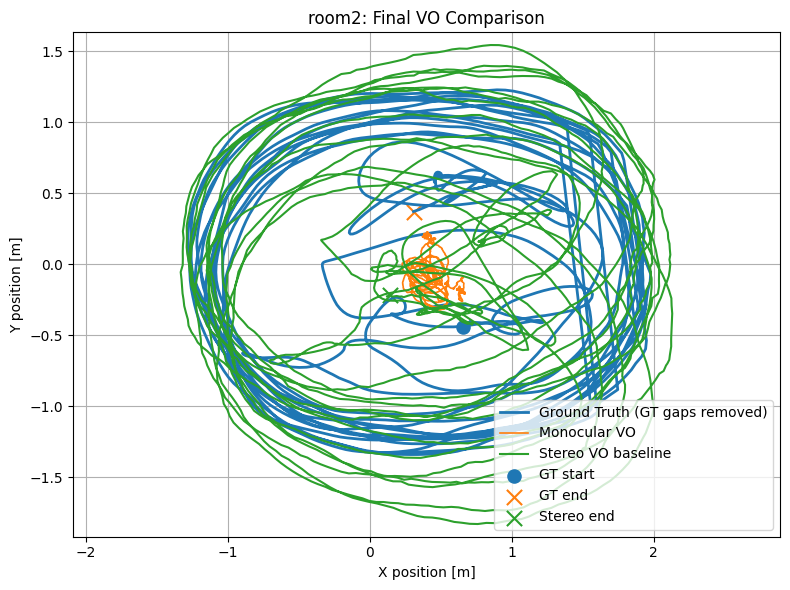

Saved plot: C:\Users\User\Desktop\Stereo_vo\outputs\room2_final_submission\room2_final_trajectory_plot.png


In [16]:
# ============================================================
# FINAL TRAJECTORY PLOT
# ============================================================

gt_plot = np.full_like(gt_xyz_all, np.nan)
gt_plot[valid_idx] = gt_xyz_all[valid_idx]

plt.figure(figsize=(8, 6))
plt.plot(gt_plot[:, 0], gt_plot[:, 1], label="Ground Truth (GT gaps removed)", linewidth=2)

if RUN_MONO:
    plt.plot(mono_full_aligned[:, 0], mono_full_aligned[:, 1], label="Monocular VO", linewidth=1.2)
if RUN_STEREO:
    plt.plot(stereo_full_aligned[:, 0], stereo_full_aligned[:, 1], label="Stereo VO baseline", linewidth=1.5)
if loop_full_aligned is not None:
    plt.plot(loop_full_aligned[:, 0], loop_full_aligned[:, 1], label="Stereo VO + visual loop correction", linewidth=2)

plt.scatter(gt_xyz_all[valid_idx[0], 0], gt_xyz_all[valid_idx[0], 1], s=90, marker="o", label="GT start")
plt.scatter(gt_xyz_all[valid_idx[-1], 0], gt_xyz_all[valid_idx[-1], 1], s=120, marker="x", label="GT end")

if loop_full_aligned is not None:
    plt.scatter(loop_full_aligned[valid_idx[-1], 0], loop_full_aligned[valid_idx[-1], 1], s=120, marker="x", label="Corrected stereo end")
elif RUN_STEREO:
    plt.scatter(stereo_full_aligned[valid_idx[-1], 0], stereo_full_aligned[valid_idx[-1], 1], s=120, marker="x", label="Stereo end")

plt.xlabel("X position [m]")
plt.ylabel("Y position [m]")
plt.title(f"{ACTIVE_DATASET}: Final VO Comparison")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()

plot_file = OUTPUT_DIR / f"{ACTIVE_DATASET}_final_trajectory_plot.png"
plt.savefig(plot_file, dpi=200)
plt.show()

print("Saved plot:", plot_file)


## 15. Save outputs


In [ ]:
# ============================================================
# SAVE SUBMISSION OUTPUTS
# ============================================================
# Saves summary CSV, config JSON, and TUM-format trajectories.

summary_file = OUTPUT_DIR / f"{ACTIVE_DATASET}_vo_summary.csv"
final_summary.to_csv(summary_file, index=False)
print("Saved summary:", summary_file)

config_file = OUTPUT_DIR / f"{ACTIVE_DATASET}_run_config.json"
config_to_save = {
    "active_dataset": ACTIVE_DATASET,
    "random_seed": RANDOM_SEED,
    "run_mono": RUN_MONO,
    "run_stereo": RUN_STEREO,
    "run_loop_correction": RUN_LOOP_CORRECTION,
    "dataset_path": str(config["path"]),
    "output_dir": str(OUTPUT_DIR),
    "stereo_params": config["stereo_params"],
    "python": sys.version,
    "platform": platform.platform(),
    "numpy": np.__version__,
    "opencv": cv2.__version__,
}
with open(config_file, "w", encoding="utf-8") as f:
    json.dump(config_to_save, f, indent=2)
print("Saved config:", config_file)

if RUN_MONO:
    mono_tum = poses_to_tum_array(image_ts[:len(poses_mono)], poses_mono)
    mono_file = OUTPUT_DIR / f"{ACTIVE_DATASET}_mono_tum.txt"
    np.savetxt(mono_file, mono_tum, fmt="%.9f %.6f %.6f %.6f %.6f %.6f %.6f %.6f")
    print("Saved mono TUM:", mono_file)

if RUN_STEREO:
    stereo_tum = poses_to_tum_array(image_ts[:len(poses_stereo)], poses_stereo)
    stereo_file = OUTPUT_DIR / f"{ACTIVE_DATASET}_stereo_baseline_tum.txt"
    np.savetxt(stereo_file, stereo_tum, fmt="%.9f %.6f %.6f %.6f %.6f %.6f %.6f %.6f")
    print("Saved stereo baseline TUM:", stereo_file)

    stereo_stats_file = OUTPUT_DIR / f"{ACTIVE_DATASET}_stereo_frame_stats.csv"
    stereo_stats_df.to_csv(stereo_stats_file, index=False)
    print("Saved stereo frame stats:", stereo_stats_file)

if poses_loop_corrected is not None:
    loop_tum = poses_to_tum_array(image_ts[:len(poses_loop_corrected)], poses_loop_corrected)
    loop_file = OUTPUT_DIR / f"{ACTIVE_DATASET}_stereo_loop_corrected_tum.txt"
    np.savetxt(loop_file, loop_tum, fmt="%.9f %.6f %.6f %.6f %.6f %.6f %.6f %.6f")
    print("Saved loop-corrected stereo TUM:", loop_file)

print("\nRequired trajectory outputs for this dataset are now in:")
print(OUTPUT_DIR)


## 16. How to use this notebook for the final submission

Run this notebook once for each required sequence:

1. `ACTIVE_DATASET = "room2"`
2. `ACTIVE_DATASET = "corridor3"`
3. `ACTIVE_DATASET = "outdoors5"`

For each run, keep the generated files in the dataset output folder:

- `*_mono_tum.txt`
- `*_stereo_baseline_tum.txt`
- `*_vo_summary.csv`
- `*_run_config.json`
- `*_final_trajectory_plot.png`
- optional: `*_stereo_loop_corrected_tum.txt` only if loop correction is enabled and reported separately.

Submission checklist from the assignment:

- GitHub repository with code, README, setup instructions, configs, seeds, reproducible scripts.
- TUM trajectory files for Room2, Corridor3, Outdoors5.
- Evaluation tables/plots for ATE, RPE, drift, and runtime.
- IEEE-style paper up to 8 pages.
- 15-minute presentation.
- Conference poster.
- Add `zaar_ali@yahoo.com` as a GitHub collaborator.

Keep the final paper/presentation honest:
- Raw stereo VO is the baseline.
- Optional loop correction must be labeled as an additional correction, not as raw stereo VO.
- Corridor3 and Outdoors5 are evaluated by start–end drift because GT is only available at the start/end.
